# PS 1

#### Biblioteca numpy:
Folosind modului random avem acces la generare de numere pseudo-aleatoare.
- rand(d1, d2, ..., dn) returneaza o structura in n dimensiuni de tip dnarray cu numere din intervalul (0,1) intr-o distributie uniforma.
- randint(low, high=None, size=None, dtype=int) returneaza __size__ elemente de tipul dtype din intervalul [low, high)
- choice(a, size=None, replace=True, p=None) returneaza __size__ alegeri aleatoare din a. replace=True inseamna ca alegerea se face cu returnare (elementul ales nu e eliminat din array)

In [ ]:
import numpy as np
n = 5
print(n, "valori aleatoare din intervalul (0,1):", np.random.rand(n))

print(n, "numere intregi aleatoare din intervalul [-1, 6):", np.random.randint(-1, 6, size=n))
help(np.random.choice)

Algoritm aleator __Las Vegas__ returneaza la fiecare executie rezultatul corect, dar durata de executie este o variabila aleatoare. Ex: random QuickSort

Algoritm aleator __Monte Carlo__ returneaza rezultate corecte doar cu o anumita probabilitate. Ex: Testul de numar prim Miller-Rabin

Evenimentul este rezultatul unei experiente al carei rezultat nu poate fi cunoscut decat dupa incheierea ei.

***Spatiul de selectie***, notat Omega, este multimea tuturor rezultatelor posibile.
Din Omega extragem submultimi numite evenimente aleatoare, sau submultimi cu un singur element numite eveniment elementar.
Din aceste submultim deducem evenimentul reuniune, intersectie, contrar/complementar, disjuncte, diferenta.

Rn(A) - numar realizari eveniment A.  = frecventa absoluta
Frecventa relativa fn(A) = Rn(A)/n  = probabilitatea ca evenimentul A sa se produca

Intr-o distributie uniforma putem aplica formula probabilitatii P(A) = cazuri favorabile / cazuri posibile
! Pentru valori mari ale lui n, frecventa relativa este aproximativ egala cu P(A)

Putem aplica formula probabilitatii si in contexte geometrice: Probabilitatea ca un punct sa apartina unei forme geometrice dintr-un spatiu mai vast posibil.

In 1933 a fost introdusa teoria axiomatica a probabilitatii in care probabilitatea de aparitie a evenimentului A a fost definita drept o functie. Astfel apare termenul de sigma-algebra care este o ***familie K de evenimente*** din spatiul de selectie Omega.

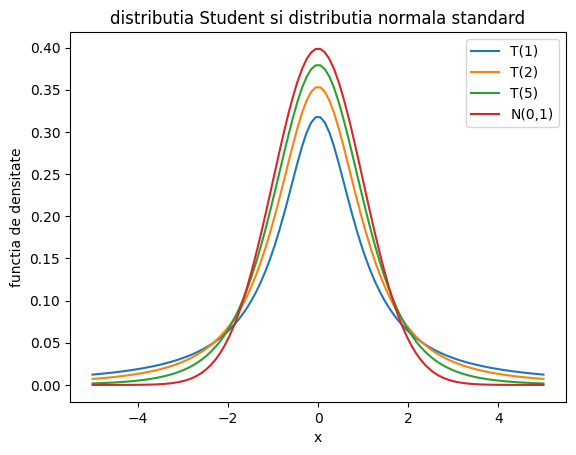

In [1]:
#Exemplu functii de densitate
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t,norm
x = np.linspace(-5, 5, 100)
degrees_of_freedom = [1, 2, 5]
# diferite grade de libertate pt distributia Student T(.)
# functii de densitate
for df in degrees_of_freedom:
    y = t.pdf(x, df)
    plt.plot(x, y, label=f"T({df})")
z0=norm.pdf(x,0,1)
plt.plot(x, z0, label="N(0,1)")
plt.xlabel("x")
plt.ylabel("functia de densitate")
plt.title("distributia Student si distributia normala standard")
plt.legend()
plt.show()

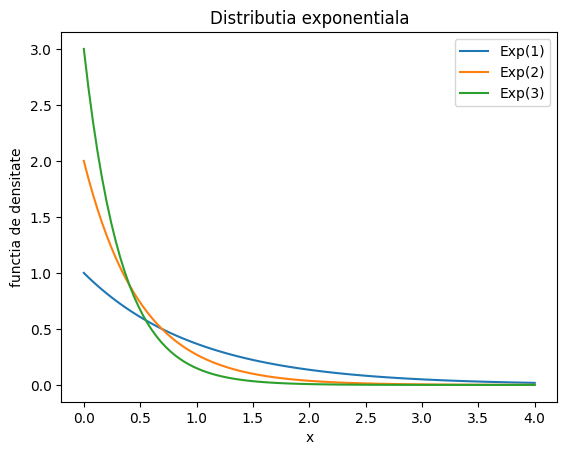

In [2]:
# functia de densitate pentru distributia exponentiala
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import expon
x = np.linspace(0, 4, 100)
L= [1, 2, 3] # valori pentru Lambda
for t in L:
    y = expon.pdf(x, scale=1/t)
    plt.plot(x, y, label=f"Exp({t})")
plt.xlabel("x")
plt.ylabel("functia de densitate")
plt.title("Distributia exponentiala")
plt.legend()
plt.show()

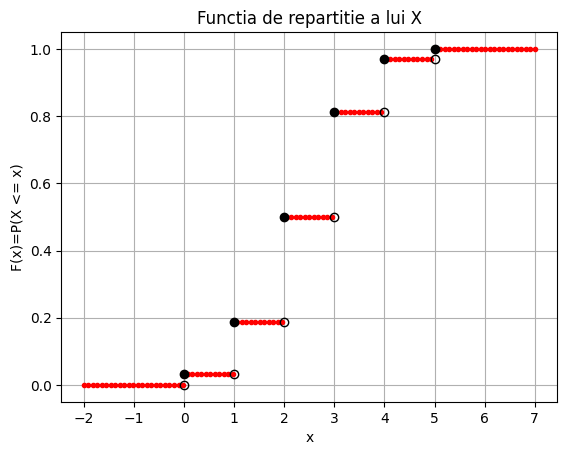

In [3]:
#Fie o urna cu 10 bile, din care 5 sunt rosii; X (v.a.)= cate bile rosii au fost extrase
#in 5 extrageri cu returnare; se reprezinta grafic functia de repartitie a lui X
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np
n=5
p=0.5
x = np.linspace(-2, n+2, 101)
y=scipy.stats.binom.cdf(x,n,p)
plt.plot(x, y, "r.")
for t in range(n+1):
    plt.plot(t, scipy.stats.binom.cdf(t,n,p), "ko")
    plt.plot(t, scipy.stats.binom.cdf(t-(n+4)/100,n,p), "ko", mfc="none")
plt.xlabel("x")
plt.ylabel("F(x)=P(X <= x)")
plt.title("Functia de repartitie a lui X")
plt.xticks(range(-2,n+3))
plt.grid()
plt.show()

In [4]:
import random; import numpy
c1,c2,a1,a2=0,0,0,0
N=10000
A= list(range(1,21))
for _ in range(N):
    i=numpy.random.randint(len(A))
    v=A[i]
    c1=c1+(v%2)
    c2=c2+((v%2)==0)
    a1=a1+(v%2)*((v%3)==0);
    a2=a2+ ((v%2)==0)*(6<=v and v<=10)
p1=a1/c1
p2=a2/c2
p3=c1/N
print(f"p1={p1:.6f}")
print(f"p2={p2:.6f}")
print(f"p3={p3:.6f}")

p1=0.299841
p2=0.304785
p3=0.502600


In [31]:
from random import sample, choice, choices, randint, randrange, random
from math import factorial, perm, comb, log, exp, dist
from itertools import combinations, permutations, combinations_with_replacement
from numpy import mean, var, std, linspace, log, exp, unique, floor
from matplotlib.pyplot import plot, xticks, yticks, grid, show

help(xticks)


Help on function xticks in module matplotlib.pyplot:

xticks(ticks: 'ArrayLike | None' = None, labels: 'Sequence[str] | None' = None, *, minor: 'bool' = False, **kwargs) -> 'tuple[list[Tick] | np.ndarray, list[Text]]'
    Get or set the current tick locations and labels of the x-axis.
    
    Pass no arguments to return the current values without modifying them.
    
    Parameters
    ----------
    ticks : array-like, optional
        The list of xtick locations.  Passing an empty list removes all xticks.
    labels : array-like, optional
        The labels to place at the given *ticks* locations.  This argument can
        only be passed if *ticks* is passed as well.
    minor : bool, default: False
        If ``False``, get/set the major ticks/labels; if ``True``, the minor
        ticks/labels.
    **kwargs
        `.Text` properties can be used to control the appearance of the labels.
    
        .. warning::
    
            This only sets the properties of the current ticks, 